# Sharper at what cost? — the benchmark in miniature

This notebook runs the whole of paper 2's comparison on a small sample: seven
classical deconvolution methods and one deep-learning pipeline, scored against
real JWST/NIRSpec grating spectra from JADES.

It needs no survey data, no GPU and no configuration. The spectra download once
from the Hugging Face Hub (1.9 MB) and everything after that is numpy and scipy.

```bash
pip install specsrbench
```

That is the whole setup. Fetching the sample is built into the base package —
no extra, no Hub account, no token.

By the end you will have reproduced the result the paper is named after: the
deep-learning model wins the obvious metric by 30%, and loses once you ask the
one extra question that metric cannot answer.

## 1. The data

24 galaxies, drawn from the 572 held out of training by a group-wise split.
Sorted by redshift and sampled at evenly spaced ranks — not chosen for how good
they look, which matters because this notebook prints performance numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from specsrbench.sample import load_sample
from specsrbench.style import use_paper_style

use_paper_style()

s = load_sample()          # downloads on first call, cached afterwards
print(s.summary())

24 held-out spectra from specsrbench_sample.npz
  grid  1.00-5.30 um (6671 pix, log R=4000)
  z     [0.310, 13.860]
  LSF   4.65-49.73 pix (derived (specsrbench build lsf))


In [2]:
# Everything travels with the archive, including where it came from.
for k, v in s.provenance.items():
    if k != "eval_set_provenance":
        print(f"{k:22s} {v}")

description            24 held-out JWST/NIRSpec spectra from JADES DR4, for the specsrbench tutorial
selection              sorted by redshift, sampled at evenly spaced ranks; not cherry-picked
n_spectra              24
drawn_from             cache_logR/eval_set.npz -- 572 held-out originals, group-wise 80/20 split
grid                   specsr DEFAULT_GRID, log, R=4000, 1.0-5.3 um, 6671 points
units                  x_low, x_high, sr2 and x_high_err are per-spectrum z-scored, which is what makes MAE comparable across spectra of very different brightness
kernel                 derived (specsrbench build lsf)
params_source          cache_logR_tuned/classical_params.json
built_by               scripts/make_tutorial_sample.py
built_from_commit      6b792465503b308c4943af0aff7d85402e353484


Each galaxy carries two spectra of the same object:

| array | what it is |
|---|---|
| `x_low` | the **prism** spectrum (R ~ 100), interpolated onto the fine grid — the input |
| `x_high` | the **grating** spectrum (R ~ 1000), the reference every method is scored against |
| `sr2` | the SR2 deep-learning prediction, precomputed so no torch is needed |
| `valid` | pixels where the reference is real rather than padding |

Both spectra are per-spectrum z-scored. That normalisation is what makes a mean
absolute error comparable across galaxies whose brightnesses differ by orders of
magnitude — but it also means **the absolute flux scale is not part of this
problem**. Nothing here predicts it.

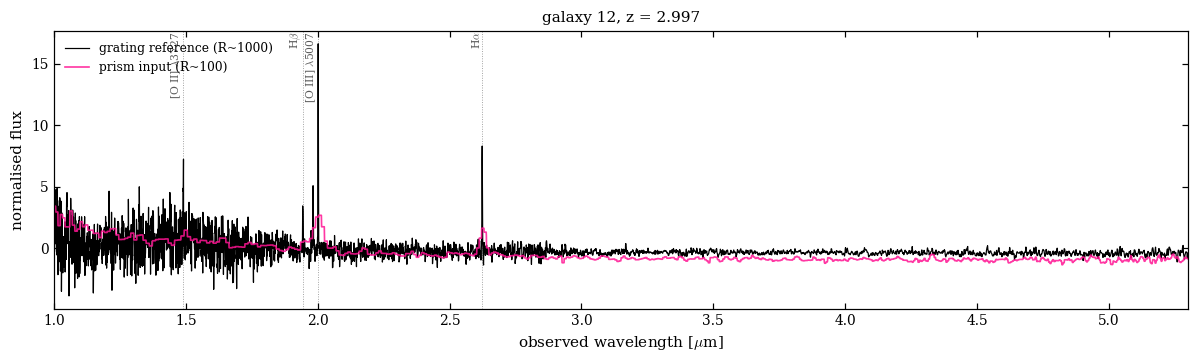

In [3]:
i = 12                                    # a mid-redshift galaxy
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(s.wave, np.where(s.valid[i], s.x_high[i], np.nan),
        color="black", lw=0.8, label="grating reference (R~1000)")
ax.plot(s.wave, s.x_low[i], color="deeppink", lw=1.1, alpha=0.85,
        label="prism input (R~100)")

for _, label, obs in s.line_positions(i):
    ax.axvline(obs, color="0.6", lw=0.6, ls=":", zorder=0)
    ax.text(obs, ax.get_ylim()[1], label, rotation=90, va="top", ha="right",
            fontsize=7, color="0.35")

ax.set(xlabel=r"observed wavelength [$\mu$m]", ylabel="normalised flux",
       title=f"galaxy {i}, z = {s.z[i]:.3f}", xlim=(s.wave.min(), s.wave.max()))
ax.legend(loc="upper left")
plt.tight_layout()

The prism traces the continuum well and turns every emission line into a broad
bump. Recovering those lines is the task.

## 2. The line-spread function

Every deconvolution method needs to know what blurred the data. The archive
carries the **measured** kernel: the LSF width in *detector pixels* at each
point of the grid.

This is worth a moment, because getting it wrong is not a subtle error. A real
spectrograph has a roughly fixed LSF in pixels; an LSF that is instead roughly
constant in *nanometres* is too broad at the red end by more than a factor of
two, and deconvolving with it merges line pairs the input still resolves. The
evaluation set ships such an array. Nothing in this sample does.

sigma_pix spans 4.6 to 49.7 pixels


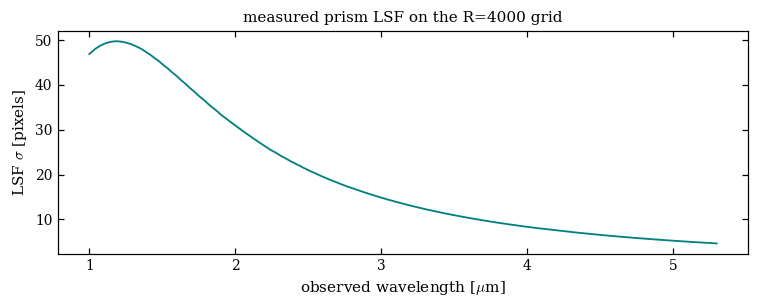

In [4]:
fig, ax = plt.subplots(figsize=(7, 2.9))
ax.plot(s.wave, s.sigma_pix, color="teal", lw=1.2)
ax.set(xlabel=r"observed wavelength [$\mu$m]",
       ylabel=r"LSF $\sigma$ [pixels]",
       title="measured prism LSF on the R=4000 grid")
plt.tight_layout()

print(f"sigma_pix spans {s.sigma_pix.min():.1f} to {s.sigma_pix.max():.1f} pixels")

## 3. Running the baselines

`reconstruct()` runs all six classical deconvolvers at the parameters the paper
tuned, which the archive carries so there is no second copy to drift. It returns
the full comparison table — the six it computed plus cubic interpolation (the
input, i.e. doing nothing) and the SR2 prediction.

In [5]:
print("tuned parameters, as `specsrbench build tune` chose them:")
for name, block in s.tuned.items():
    print(f"  {name:9s} {block}")

recon = s.reconstruct()    # a few seconds
print("\n" + ", ".join(recon))

tuned parameters, as `specsrbench build tune` chose them:
  wiener    {'snr': 8.0, 'segment_len': 128, 'overlap': 32}
  tikhonov  {'lam': 10.0, 'segment_len': 512, 'overlap': 128}
  rl        {'n_iter': 1}
  sparse    {'lam': 0.05, 'n_iter': 1}
  tv        {'lam': 0.1, 'n_iter': 30}
  mf        {'window_nsigma': 4.0, 'detect_snr': 5.0, 'core_nsigma': 3.0, 'sideband_nsigma': 2.0, 'width_scale': 0.2}



Cubic (LR), Wiener, Tikhonov, TV, R-L, Sparse, Wiener + MF, ML (SR2)


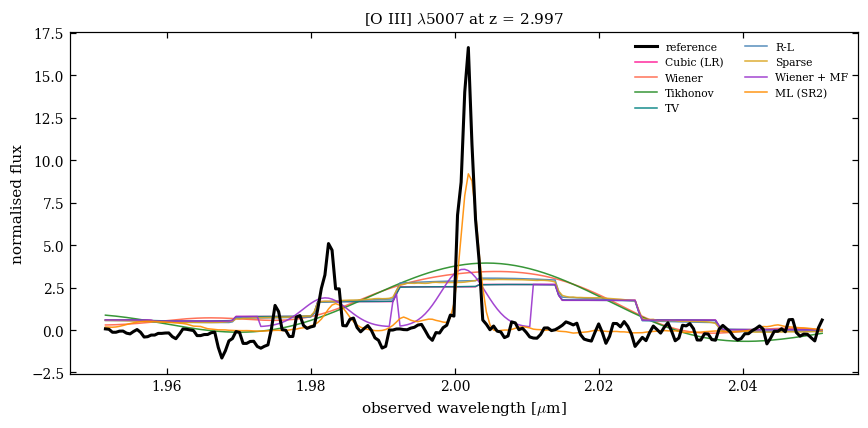

In [6]:
from specsrbench.methods import registry

reg = registry()
lab2key = {m.label: k for k, m in reg.items()}

# Zoom on the strongest line in this galaxy.
_, label, obs = max(s.line_positions(i), key=lambda t: np.nanmax(
    np.where(np.abs(s.wave - t[2]) < 0.01, s.x_high[i], np.nan)))
w = (s.wave > obs - 0.05) & (s.wave < obs + 0.05)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s.wave[w], s.x_high[i][w], color="black", lw=2.0, label="reference", zorder=5)
for name, arr in recon.items():
    ax.plot(s.wave[w], arr[i][w], lw=1.0, alpha=0.9,
            color=reg[lab2key[name]].color, label=name)
ax.set(xlabel=r"observed wavelength [$\mu$m]", ylabel="normalised flux",
       title=f"{label} at z = {s.z[i]:.3f}")
ax.legend(ncol=2, fontsize=7)
plt.tight_layout()

## 4. Scoring — and the question MAE cannot answer

Now the table. Three columns, and the paper's argument lives in the gap between
the first and the second:

- **MAE** — mean absolute error against the reference.
- **MAE (scale-free)** — the same, after each spectrum is rescaled by its own
  least-squares optimal gain. Invariant under any global rescale *by
  construction*.
- **std ratio** — output amplitude over reference amplitude. 1.0 means the
  amplitude was preserved.

In [7]:
import pandas as pd
from specsrbench.metrics import mae, mae_scalefree, std_ratio

rows = [{
    "Method": name,
    "MAE": mae(arr, s.x_high, s.valid),
    "MAE (scale-free)": mae_scalefree(arr, s.x_high, s.valid),
    "std ratio": std_ratio(arr, s.x_high, s.valid),
} for name, arr in recon.items()]

table = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
table["rank by MAE"] = table.index + 1
table["rank scale-free"] = table["MAE (scale-free)"].rank().astype(int)
table.style.format({"MAE": "{:.4f}", "MAE (scale-free)": "{:.4f}",
                    "std ratio": "{:.3f}"})

,Method,MAE,MAE (scale-free),std ratio,rank by MAE,rank scale-free
0,ML (SR2),0.4842,0.4797,0.575,1,8
1,Wiener + MF,0.7064,0.4753,0.975,2,6
2,TV,0.7151,0.4737,0.990,3,1
3,Cubic (LR),0.7159,0.4739,0.991,4,2
4,Wiener,0.7220,0.4743,1.002,5,3
5,R-L,0.7282,0.4748,1.022,6,5
6,Sparse,0.7293,0.4748,1.025,7,4
7,Tikhonov,0.7775,0.4786,1.147,8,7


Read the last two columns together.

**ML (SR2) is first by MAE and last once the scale is taken out.** Its `std
ratio` says why: the prediction has substantially less amplitude than the
reference it is being compared against. Against a noisy target, shrinking
everything toward zero lowers absolute error — whatever the reconstruction is
actually worth.

That is not an argument that SR2 is a bad model. It is an argument that MAE
alone cannot tell you whether it is a good one.

### The trap, demonstrated

You do not have to take the argument on faith. Take cubic interpolation — a
method that does *nothing* — and simply multiply it by a constant. No
information is added or removed by a global rescale.

MAE at gain 1.00 (no rescale) : 0.7159
MAE at gain 0.40 (shrunk)   : 0.5299   <-- 26% 'better'
scale-free MAE varies across the whole sweep by 0.00e+00


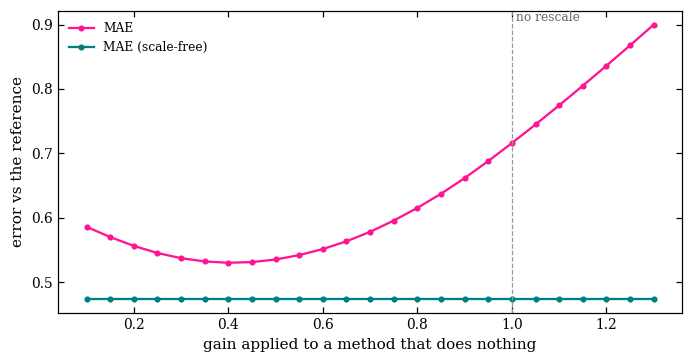

In [8]:
nothing = recon["Cubic (LR)"]
gains = np.linspace(0.1, 1.3, 25)
m  = np.array([mae(g * nothing, s.x_high, s.valid) for g in gains])
sf = np.array([mae_scalefree(g * nothing, s.x_high, s.valid) for g in gains])

honest = int(np.argmin(np.abs(gains - 1.0)))       # the un-rescaled spectrum
best   = int(np.argmin(m))

print(f"MAE at gain 1.00 (no rescale) : {m[honest]:.4f}")
print(f"MAE at gain {gains[best]:.2f} (shrunk)   : {m[best]:.4f}"
      f"   <-- {(m[honest] - m[best]) / m[honest]:.0%} 'better'")
print(f"scale-free MAE varies across the whole sweep by "
      f"{sf.max() - sf.min():.2e}")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(gains, m, "o-", color="deeppink", ms=3, label="MAE")
ax.plot(gains, sf, "o-", color="teal", ms=3, label="MAE (scale-free)")
ax.axvline(1.0, color="0.6", lw=0.8, ls="--")
ax.text(1.0, ax.get_ylim()[1], " no rescale", va="top", fontsize=8, color="0.4")
ax.set(xlabel="gain applied to a method that does nothing",
       ylabel="error vs the reference")
ax.legend()
plt.tight_layout()

Shrinking a method that does nothing, until it retains under half the
reference's amplitude, "improves" its MAE by roughly a quarter. The scale-free
curve does not move at all — not approximately, but to machine precision,
because it is invariant under a global rescale by construction and a global
rescale genuinely carries no information.

Any tuning loop that minimises MAE will find that minimum and sit in it. This
project's did, more than once.

## 5. What actually survives

Amplitude is only the second of four ways MAE misleads, and no one guard catches
the others:

1. **Smoothing** — erase every line and you incur no line-shaped residual.
   *Guard:* median line S/N against the no-deconvolution baseline.
2. **Shrinkage** — the effect above. *Guard:* `std_ratio` inside [0.90, 1.15].
   Line S/N is blind to this: it is amplitude over sideband noise, so a global
   rescale leaves it unchanged.
3. **Blurring** — a unit-gain Wiener filter with `snr <= 1` peaks at zero
   frequency, so it cannot amplify anything and can only broaden lines.
   *Guard:* median line FWHM bias. The amplitude guard is width-invariant and
   cannot see it.
4. **Merging** — a method can pass all three and still smear a close doublet
   into one peak, because a Gaussian fitted to a blend looks much like one
   fitted to a separated pair. *Guard:* the fraction of resolvable [O III]
   pairs kept resolved.

Each of these cost a rebuild before it was caught. `specsrbench build tune`
applies all four inside the search rather than after it. The
[guards guide](https://aryana-haghjoo.github.io/specsr-benchmark/guides/guards.html)
is the long version.

So what does survive? Something more interesting than a leaderboard. SR2 does
not reconstruct the reference better than cubic interpolation does — but it
produces lines that are *cleaner than the reference's own*, while recovering
only a third to a half of their true amplitude, and it invents lines that are
not there at rates no classical method approaches. Figure 5 of the paper is that
result; the sample below is a glimpse of it.

In [9]:
# Amplitude retained, per method, on this sample.
for name, arr in sorted(recon.items(), key=lambda kv: -std_ratio(kv[1], s.x_high, s.valid)):
    r = std_ratio(arr, s.x_high, s.valid)
    flag = "" if 0.90 <= r <= 1.15 else "   <-- outside the amplitude guard"
    print(f"  {name:14s} std ratio {r:5.3f}{flag}")

  Tikhonov       std ratio 1.147
  Sparse         std ratio 1.025
  R-L            std ratio 1.022
  Wiener         std ratio 1.002
  Cubic (LR)     std ratio 0.991
  TV             std ratio 0.990
  Wiener + MF    std ratio 0.975
  ML (SR2)       std ratio 0.575   <-- outside the amplitude guard


Only SR2 falls outside the band, and it falls a long way outside it. Tikhonov
sits just inside the upper edge — and that is not a clean pass. It is there
because it is *held* there: pushing its regularisation any harder brings the
amplitude down but merges close line pairs, and no setting satisfies both that
guard and the amplitude guard at once. The paper retains it and says so, and the
archive carries the tuner's own note rather than hiding it.

In [10]:
for method, reason in s.params["failed_guards"].items():
    print(f"{method}:\n  {reason}")

tikhonov:
  no setting satisfies both the amplitude and the pair guard: searched 5 segment lengths x 10 lambda, and wherever lambda is large enough to bring std under 1.15 the pair has already merged to ~31%. Retained at the shipped value.


## 6. Deconvolving a spectrum of your own

The deconvolvers in `specsrbench.classical` take a 1-D array and a per-pixel
kernel width; nothing about them is specific to this dataset. The one thing you
must supply honestly is the kernel — **in detector pixels of the grid your
spectrum is on**, not in wavelength units.

In [11]:
from specsrbench import classical as C

spectrum = s.x_low[3]                     # substitute your own, z-scored
kernel   = s.sigma_pix                    # substitute your own instrument's LSF

wiener = C.wiener_deconv(spectrum, kernel, **s.tuned["wiener"])
rl     = C.rl_deconv(spectrum, kernel, **s.tuned["rl"])

print(f"input  std {spectrum.std():.3f}")
print(f"Wiener std {wiener.std():.3f}   (ratio {wiener.std() / spectrum.std():.3f})")
print(f"R-L    std {rl.std():.3f}   (ratio {rl.std() / spectrum.std():.3f})")

input  std 1.000
Wiener std 0.992   (ratio 0.992)
R-L    std 1.017   (ratio 1.017)


Check that ratio before you trust anything downstream of it. If a deconvolution
has changed the amplitude of your spectrum substantially, it has done something
other than sharpen it, and an error metric computed against a noisy reference
will not tell you.

The tuned parameters above are tuned **for this instrument, this grid and this
kernel**. On your own data they are a starting point, not a result.

## Where to go next

- **[Guards](https://aryana-haghjoo.github.io/specsr-benchmark/guides/guards.html)** —
  the four failure modes in full, and how the tuner enforces them.
- **[Rebuilding](https://aryana-haghjoo.github.io/specsr-benchmark/guides/rebuilding.html)** —
  running the real benchmark on all 572 spectra from JADES DR4 and the Hub weights.
- **[Figures](https://aryana-haghjoo.github.io/specsr-benchmark/guides/figures.html)** —
  `specsrbench figures all`, the six figures in the paper.
- **[`specsr`](https://github.com/aryana-haghjoo/specsr)** — the deep-learning
  pipeline being benchmarked, and paper 1
  ([arXiv:2603.18357](https://arxiv.org/abs/2603.18357)).

```{admonition} These are 24 galaxies, not 572
The ordering of the methods here reproduces the paper's and so does the lesson,
but the individual numbers carry the error bar of a small sample and are not the
paper's. Quote the paper for the paper's numbers.
```